# Étape 2 EXTRA — Analyse des sentiments des conversations

## Notebook annoté

Le but est le même que pour l'étape 2, implémenter un **classificateur de sentiments** sur des textes liés à la santé mentale.  
Ce notebook est une partie complémentaire implémentant une nouvelle méthodes supervisée: BERT.  

Le corpus d'entraînement utilisé est le dataset *Sentiment Analysis for Mental Health* (`Combined_Data.csv`) disponible sur Kaggle.

Nous allons définir 3 modèles différents de BERT:  
- La méthode **sans** aucun *fine-tuning* (permettant de se familiariser avec le modèle)
- Cette méthode **avec** *fine-tuning* sur notre dataset
- Importer un BERT **pré-entraîné sur des analyses de sentiments** (modèle importé depuis [Hugging Face](https://huggingface.co/)) que l'on fine-tune par la suite sur notre dataset

Ma partie personnelle se focalisera sur la troisième partie: importer un BERT **pré-entraîné sur des analyses de sentiments**.
Le groupe devra traiter les deux autres méthodes de leurs côté afin de comparer les performances de chacune d'entre elles.

Pour chaque modèle, on appliquera les mêmes analyses que pour l'étape 2 (accuracy score, classification report et matrice de confusion) afin de comparer les modèles entre eux.

---

## Table des matières

- [1. Introduction](#1-introduction)
  - [1.1. Tout d'abord, qu'est ce que BERT ?](#11-tout-dabord-quest-ce-que-bert-)
  - [1.2. Étapes d'apprentissages de BERT](#12-étapes-dapprentissages-de-bert)
  - [1.3. Ce qui fait la force de BERT...](#13-ce-qui-fait-la-force-de-bert)
  - [1.4. ...mais aussi ces faiblesses](#14-mais-aussi-ces-faiblesses)
- [2. Initialisation](#2-initialisation)
  - [2.1. Imports et dépendances](#21-imports-et-dépendances)
  - [2.2. Chargement et préparation des données](#22-chargement-et-préparation-des-données)
  - [2.3. Découpage Train / Test](#23-découpage-train--test)
  - [2.4. Encodage des labels](#24-encodage-des-labels)
- [3. Modèle C — BERT pré-entraîné sur sentiments (Hugging Face) + fine-tuning](#3-modèle-c--bert-pré-entraîné-sur-sentiments-hugging-face--fine-tuning)
  - [3.1. Pourquoi utiliser un modèle spécialisé ?](#31-pourquoi-utiliser-un-modèle-spécialisé-)
  - [3.2. Chargement du modèle spécialisé](#32-chargement-du-modèle-spécialisé)
  - [3.3. Adaptation de la tête de classification](#33-adaptation-de-la-tête-de-classification)
  - [3.4. Fine-tuning sur notre dataset](#34-fine-tuning-sur-notre-dataset)
  - [3.5. Évaluation](#35-évaluation)
- [4. Comparaison des modèles](#4-comparaison-des-modèles)

---

## 1. Introduction

### 1.1. Tout d'abord, qu'est ce que BERT ?

BERT (*Bidirectional Encoder Representation from Transformer*) est un modèle de language développé par Google en 2018.  

BERT repose sur l'architecture **Transformer**, mais n'en utilise que la partie **encodeur**. Sa particularité fondamentale est d'être **bidirectionnel**: contrairement aux modèles précédents qui lisaient le texte de gauche à droite (ou l'inverse), **BERT lit le contexte dans les deux direction simultanément.**.

> "Le chat mange la souris" → BERT comprend "mange" en regardant à la fois "chat" (gauche) et "souris" (droite).

### 1.2. Étapes d'apprentissages de BERT

**Pré-entraînement (non supervisé)**
Avant toute tâches spécifiques, BERT est pré-entraîné sur d'énormes corpus (Wikipedia, BooksCorpus etc.) via deux tâches:  
- **Masked Language Model (MLM)**: on masque ~15% des tokens au hasard et le modèle doit les prédire. Ex: "Le [MASK] mange la souris" → prédit "chat"
- **Next Sentence Prediction (NSP)**: le modèle apprend si deux phrases se suivent logiquement ou non.

**Fine-tuning supervisé**  
C'est ici qu'intervient l'apprentissage **supervisé**. On reprend BERT pré-entraîné et on l'adapte à une tâche précise avec des données étiquetées, en ajoutant une petite couche de sortie:  

| Tâche | Exemple | Ce qu'on ajoute |
|-|-|-|
| Classification de texte | Sentiment positif/négatif | Couche dense sur le token [CLS] |
| NER | Identifier noms, lieux... | Couche dense sur chaque token |
| Question-Réponse | Extraire la réponse d'un passage | Deux classifieurs (début/fin de span) |
| Similarité de phrases | Les phrases sont-elles équivalentes ? | Couche dense sur [CLS] |

Le fine-tuning ne nécessite que peu de données étiquetées et peu d'epochs, car BERT a déjà appris une représentation riche du langage.

**Tokenisation spécifique**  
BERT utilise **WordPiece tokenizer**: les mots rares sont découpés en sous-mots

```"unhapiness" → ["un", "##happi", "##ness"]```  

Et ajoute des tokens spéciaux:  
- `[CLS]` en début de séquence (représente la phrase entière)
- `[SEP]` pour séparer deux segments  

### 1.3 Ce qui fait la force de BERT...
- Les représentations sont **contextuelles** : le mot "banque" n'a pas le même vecteur dans "banque financière" et "banque de sable".  
- Le transfert de connaissances est très efficace : un BERT pré-entraîné une fois peut être fine-tuné pour des dizaines de tâches différentes.  
- Des variantes existent pour différents besoins : **RoBERTa** (plus robuste), **CamemBERT** (français), **DistilBERT** (plus léger), etc.  

### 1.4 ...mais aussi ces faiblesses

#### Coût computationnel élevé
Probablement la limitation la plus concrète:
- BERT-base: 110 million de paramètres
- BERT-large: 340 millions de paramètres
- L'attention est en $O(n^2)$ par rapport à la longueur de la séquence, donc extrèmement coûteux sur les longs textes
- Fine-tuning et inférence nécessitent un GPU pour être résonnables en temps

#### Limite de longueur des séquences
BERT est limité à **512 tokens** en entrée. C'est un problème réel pour:
- Les documents longs (articles, contrats, rapports)
- Le texte doit être **tronqué ou découpé**, ce qui peut faire perdre du contexte

> Des variantes comme **Longformer** ou **BigBird** ont été créées pour palier ce problème.

---

## 2. Initialisation

### 2.1. Imports et dépendances

Ce notebook nécessite les bibliothèques suivantes :

| Bibliothèque | Rôle |
|---|---|
| `transformers` (Hugging Face) | Chargement des modèles BERT et tokeniseurs pré-entraînés |
| `torch` | Framework deep learning pour l'entraînement et l'inférence |
| `torch.utils.data` | `Dataset` et `DataLoader` pour créer des batchs d'entraînement |
| `sklearn` | Métriques d'évaluation, encodage des labels, découpage train/test |
| `numpy`, `pandas` | Manipulation des données |
| `matplotlib`, `seaborn` | Visualisation des résultats |

> ⚠️ **Prérequis** : installer `transformers` et `torch` si ce n'est pas déjà fait :
> ```bash
> pip install transformers torch
> ```

> 💡 **GPU recommandé** : BERT est très coûteux en calcul. Vérifiez la disponibilité d'un GPU avec `torch.cuda.is_available()`.  
> Sur Google Colab, activer le runtime GPU dans *Exécution → Modifier le type d'exécution*.


**Ce que nous faisons ici:**

1. Importer toutes les bibliothèques listées ci-dessus
2. Détecter et afficher le device disponible (`cuda` ou `cpu`) — toutes les opérations PyTorch devront être effectuées sur ce device
3. Fixer les seeds de reproductibilité (`random`, `numpy`, `torch`) à 42

In [ ]:
# Import des bibliothèques

# transformers
import transformers
# torch
import torch
from torch.utils.data import Dataset, DataLoader

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    r2_score,
    classification_report,
    ConfusionMatrixDisplay
)

# numpy
import numpy as np
# pandas
import pandas as pd
# matplotlib
import matplotlib.pyplot as plt
# seaborn
import seaborn as sns
# regex
import re

In [ ]:
# On détecte et affiche le device disponible (cuda ou cpu)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# On fixe les seeds de reproductibilité
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

### 2.2. Chargement et préparation des données

On réutilise exactement le même pipeline de nettoyage que dans le notebook principal (ETAPE2) :  
chargement → mélange → suppression des NaN → suppression des conflits → nettoyage du texte (`cleaner`).

> ⚠️ **Ne pas** réappliquer la tokenisation NLTK ni la vectorisation BoW/TF-IDF/Word2Vec : BERT dispose de son propre tokeniseur (`BertTokenizer`) qui sera utilisé directement sur le texte nettoyé.

**Ce que nous faisons ici :**

1. Charger `Combined_Data.csv` dans un DataFrame `df`
2. Mélanger les lignes (`sample(frac=1, random_state=42)`) et réinitialiser l'index
3. Supprimer les lignes avec des valeurs manquantes (`dropna`)
4. Supprimer les énoncés avec des étiquettes conflictuelles (même logique que dans le notebook principal)
5. Appliquer la fonction `cleaner` sur la colonne `statement`
6. Séparer `X` (textes nettoyés) et `y` (labels)

In [ ]:
# Fonction cleanner pour nettoyer les énoncés
def cleaner(text):
    text = re.sub(r'\s*@\w+', '', text)                            # remove words starting with @
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)            # remove URLs
    text = re.sub(r'<[^>]*>', '', text)                            # remove all of the HTML markup
    #text = re.sub(r'\b\w\b', '', text)                             # remove single letters, I, a, ...
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)  # find emoticons (emoji)
    text = (re.sub(r'[\W]+', ' ', text.lower()) + ' '.join(emoticons).replace('-', ''))
    #  replace any non_word with space, lowercase words, add emojis at the end
    return text

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# On charge combined_data.csv
# df = pd.read_csv('/content/drive/MyDrive/PAULSAB/L3-3/BE/Analyse-de-conversations-sur-la-sant-mentale-main/data/combined_data.csv')
df = pd.read_csv('data/combined_data.csv')
# On mélange les lignes du dataframe et on réinitialise les index
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
# On supprime les lignes avec des valeurs manquantes
df = df.dropna()
# On supprime les énoncés avec des étiquettes conflictuelles
df = df[df.groupby('statement')['status'].transform('nunique') == 1]
# On applique la fonction cleaner sur la colonne statement
df.loc[:, 'statement'] = df['statement'].apply(cleaner)
# On sépare X (textes nettoyés) et y (labels)
X = df['statement']
y = df['status']

### 2.3. Découpage Train / Test

Contrairement au notebook principal, un simple découpage en deux ensembles suffit ici. Le fine-tuning de BERT converge rapidement (2–3 epochs) et les hyperparamètres sont peu nombreux, ce qui rend l'ensemble de validation optionnel.

**Ce que nous faisons ici:**

1. Effectuer un `train_test_split` (80% train, 20% test) avec `stratify=y` et `random_state=42`
2. Afficher les tailles de chaque ensemble

In [ ]:
# Découpage Train/Test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

Train size: 42105 | Test size: 10527


### 2.4. Encodage des labels

PyTorch exige des **entiers** comme labels (et non des chaînes de caractères). On utilise `LabelEncoder` de `sklearn.preprocessing` pour convertir les étiquettes textuelles en indices numériques.

> ⚠️ Le `LabelEncoder` doit être fitté **uniquement sur `y_train`**, puis appliqué en `.transform` sur `y_val` et `y_test`. Cela évite tout **data leakage**.

**Ce que nous faisons ici:**

1. Instancier un `LabelEncoder` et le fitter sur `y_train`
2. Transformer `y_train` et `y_test` en tableaux d'entiers
3. Afficher le mapping label → entier (`encoder.classes_`) et le nombre de classes (`num_labels`)

> 💡 On conserve le `LabelEncoder` fitté pour l'inférence finale : il permettra de reconvertir les prédictions numériques en noms de sentiments.

In [ ]:
# Encodage des labels avec LabelEncoder (fit uniquement sur y_train)
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)
num_labels = len(encoder.classes_)
print('Label classes:', encoder.classes_)
print('Num labels:', num_labels)

Label classes: ['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']
Num labels: 7


---

## 3. Modèle C — BERT pré-entraîné sur sentiments (Hugging Face) + fine-tuning

### 3.1. Pourquoi utiliser un modèle spécialisé ?

Le Modèle B part de `bert-base-uncased`, pré-entraîné sur Wikipedia et BooksCorpus — un texte très différent du langage émotionnel ou clinique. Le Modèle C part d'un BERT **déjà fine-tuné sur des tâches d'analyse de sentiments**, ce qui lui donne une meilleure représentation initiale des émotions avant même de voir notre dataset.

```mermaid
flowchart LR

    A["bert-base-uncased"]
    B["Pré-entraîné sur<br/>Wikipedia / BooksCorpus<br/>(langage général)"]
    C["Fine-tuning sur datasets<br/>de sentiments<br/>(Twitter, avis clients...)"]
    D["Modèle spécialisé<br/>(point de départ du Modèle C)"]
    E["Fine-tuning sur notre dataset<br/>(santé mentale)"]
    F["Modèle C final"]

    A --> B
    B --> C
    C --> D
    D --> E
    E --> F
```

| | BERT-base (Modèle B) | Modèle spécialisé (Modèle C) |
|---|---|---|
| Pré-entraînement initial | Wikipedia / BooksCorpus | Wikipedia / BooksCorpus |
| Fine-tuning intermédiaire | ❌ | ✅ Sentiments (SST-2, Twitter...) |
| Point de départ | Général | Spécialisé |
| Fine-tuning sur notre data | ✅ | ✅ |
| Performances attendues | Bonnes | Meilleures (théoriquement) |  


Il existe une très grande variété de modèles utilisant BERT sur les sentiments, qui ont toutes leurs points forts:

| Modèle | Base | Pré-entraîné sur... | Classes | Points forts |
|-|-|-|-|-|
| `cardiffnlp/twitter-roberta-base-sentiment-latest` | RoBERTa | ~124M tweets | 3 (neg/neu/pos) | Texte informel, émotions brutes |  
| `nlptown/bert-base-multilingual-uncased-sentiment` | BERT multilingual | Avis produits | 5 étoiles | Multi-langue, mais moins précis en anglais pur |
| `siebert/sentiment-roberta-large-english` | RoBERTa-large | 15 datasets variés | 2 (pos/neg) | Très haut score de généralisation |
| `j-hartmann/emotion-english-distilroberta-base` | DistilRoBERTa | 6 datasets émotions | 7 émotions | Spécialisé **émotions** (joy,anger,sadness...) |


*On remarque par la même occasion qu'une grande majorité d'entre eux utilise des variantes de BERT*  
### 3.2. Différentes base BERT

#### a. RoBERTa (*"Robustly Optimized BERT Pretrained Approach"*)
BERT amélioré par Facebook (2019). Même architecture de base, mais avec des choix d'entraînement bien meilleurs:
- **Suppression du NSP** (jugé inutile)
- Entraîné sur **10 fois plus de données** (160 Go vs ~ 16 Go)
- **Dynamic masking**: les tokens masqués changent à chaque epoch au lieu d'être figés
- Entraîné plus longtemps avec de plus gros batchs

En pratique, RoBERTa surpasse BERT-base sur presque toutes les tâches de classification et est concidéré comme la base la plus utilisée aujourd'hui pour le sentiments.

#### b. DistilBERT
Une version **distillé** de BERT-base par Hugging Face (2019).  
Le principe: on entraîne un petit modèle (66M de paramètres, 6 couches) à imiter le comportement du grand.  
Résultat:
- **40% plus rapide**
- **40% plus léger**
- Conserve ~97% des performances de BERT-base

Il est grandement choisi pour éviter les contraintes GPU ou le temps d'inférence. En revanche, sur une tâche difficile comme la santé mentale avec plusieurs classes, le perte de capacité peut se faire sentir

#### c. RoBERTa-large
La version "grande" de RoBERTa: 355M de paramètres, 24 couches au lieu de 12.  
Significativement plus performantes que RoBERTa-base, mais aussi bien plus coûteux à fine-tuner.

### 3.3. Chargement du modèle spécialisé

**Ce que vous devez faire :**

1. Choisir un modèle pré-entraîné sur des sentiments depuis Hugging Face.  
Dans notre cas, on choisira `j-hartmann/emotion-english-distilroberta-base`

2. Charger le tokeniseur correspondant (`AutoTokenizer.from_pretrained(model_name)`)
3. Re-tokeniser `X_train` et `X_test` avec ce nouveau tokeniseur
4. Recréer les `Dataset` et `DataLoader` avec les nouveaux tenseurs

> ⚠️ Chaque modèle Hugging Face a son propre tokeniseur. Utiliser `AutoTokenizer` plutôt que `BertTokenizer` directement permet de charger automatiquement le bon tokeniseur associé au modèle choisi.

In [ ]:
# 1. On choisit le modèle j-hartmann/emotion-english-distilroberta-base
model_name = 'j-hartmann/emotion-english-distilroberta-base'
# 2. On charge le tokenizer associé
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
# 3 Re-tokeniser X_train et X_test avec ce nouveau tokeniseur
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(X_test), truncation=True, padding=True, max_length=128)
# Récréer les Dataset et DataLoader avec les nouveaux tenseurs encodés
# On crée une classe Dataset personnalisée pour notre tâche d'émotion
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
# On crée les datasets et dataloaders pour l'entraînement et le test
train_dataset = EmotionDataset(train_encodings, y_train_enc)
test_dataset = EmotionDataset(test_encodings, y_test_enc)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Train batches: 2632 | Test batches: 658


### 3.4. Adaptation de la tête de classification

Le modèle importé a été fine-tuné pour un certain nombre de classes (souvent 2 ou 3 pour des tâches positif/négatif/neutre). Notre dataset a `num_labels` classes différentes. Il faut donc **remplacer la tête de classification** par une nouvelle couche adaptée à notre nombre de classes.

**Ce que vous devez faire :**

1. Charger le modèle avec `AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, ignore_mismatched_sizes=True)` et le placer sur le device

   > 💡 Le paramètre `ignore_mismatched_sizes=True` est nécessaire car la tête de classification originale (ex. 2 classes) est remplacée par une nouvelle tête à `num_labels` classes — les dimensions ne correspondent plus.

2. Instancier un nouvel optimiseur `AdamW` et un scheduler

3. Afficher l'architecture du modèle pour vérifier que la couche de sortie a bien `num_labels` neurones

In [ ]:
# 1. Charger le modèle et le placer sur le device
model = transformers.AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, ignore_mismatched_sizes=True)
model.to(device)
# 2. Instancier un nouvel optimiseur `AdamW` et un scheduler (mêmes hyperparamètres que section 4.3)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
num_epochs = 3
num_training_steps = num_epochs * len(train_loader)
lr_scheduler = transformers.get_scheduler(
    name='linear',
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)
print("=================================================")
print(f'Nombre d\'étapes de formation: {num_training_steps}')
# 3. Afficher l'architecture du modèle pour vérifier que la couche de sortie a bien `num_labels` neurones
print(f'Architecture du modèle: {model}')

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Nombre d'étapes de formation: 7896
Architecture du modèle: RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in

### 3.5. Fine-tuning sur notre dataset

La boucle d'entraînement est identique à celle du Modèle B. Seul le modèle chargé change.

> 💡 **Peut-on réutiliser exactement le même code ?** Oui, à condition d'avoir recréé les `DataLoader` avec le tokeniseur du modèle C. La boucle d'entraînement elle-même est indépendante du modèle choisi.

**Ce que vous devez faire :**

1. Réutiliser la même boucle d'entraînement que la section 4.4 (ou l'encapsuler dans une fonction réutilisable `train_model(model, train_loader, optimizer, scheduler, num_epochs, device)`)
2. Afficher la loss d'entraînement à chaque epoch
3. (Optionnel) Comparer les courbes de loss par epoch avec le Modèle B sur un même graphique

> ⚠️ **Temps d'exécution** : similaire au Modèle B. Si vous utilisez DistilBERT, comptez environ 40% de temps en moins par rapport à BERT-base.

> Temps approximatif sur GPU (RTX 4060): ~25min

In [ ]:
# Initialisé la boucle d'entraînement
def train_model(model, train_loader, optimizer, lr_scheduler, device):
    model.train()
    loss_history = []
    for epoch in range(num_epochs):
        total_loss = 0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f'Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}')
    return loss_history

In [ ]:
loss_history = train_model(model, train_loader, optimizer, lr_scheduler, device)

Epoch 1/3 | Loss: 0.6483
Epoch 2/3 | Loss: 0.4305
Epoch 3/3 | Loss: 0.3156


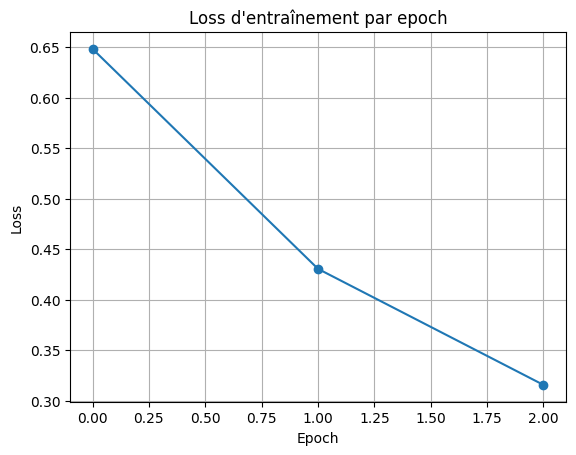

In [ ]:
# On affiche les courbes de loss de l'entrainement
plt.plot(loss_history, marker='o')
plt.title('Loss d\'entraînement par epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.show()

### 3.6. Évaluation

**Ce que vous devez faire :**

1. Appliquer la fonction `predict` (définie en section 4.5) sur `test_loader_C` pour obtenir `y_pred_C`

2. Calculer et afficher les métriques :

| Métrique | Fonction sklearn |
|---|---|
| **Accuracy** | `accuracy_score` |
| **Classification report** | `classification_report` |
| **Matrice de confusion** | `ConfusionMatrixDisplay.from_predictions` |

In [ ]:
def evaluate(name, y_true_enc, y_pred_enc):


    acc = accuracy_score(y_true_enc, y_pred_enc)
    mse = mean_squared_error(y_true_enc, y_pred_enc)
    r2  = r2_score(y_true_enc, y_pred_enc)

    print(f"\n{'═'*50}")
    print(f"  {name}")
    print(f"{'═'*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  MSE      : {mse:.4f}")
    print(f"  R²       : {r2:.4f}")

    print(
        classification_report(
            y_true_enc,
            y_pred_enc,
            target_names=encoder.classes_
        )
    )

    fig, ax = plt.subplots(figsize=(10, 8))

    ConfusionMatrixDisplay.from_predictions(
        y_true_enc,
        y_pred_enc,
        display_labels=encoder.classes_,
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )

    ax.set_title(
        f"Confusion Matrix — {name}",
        fontsize=13,
        fontweight='bold'
    )

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

    return acc, mse, r2, y_pred_enc

In [ ]:
# Fonction de prédiction
def predict(model, dataloader, device):
    # Mode évaluation
    model.eval()
    # Liste des vrais y et ceux prédit
    y_true = []
    y_pred = []
    # Désactive les gradients
    with torch.no_grad():
        # Parcours des batchs
        for batch in dataloader:
            # Envoi GPU
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # FORWARD PASS
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits

            # PRÉDICTIONS
            predictions = torch.argmax(
                logits,
                dim=1
            )

            # STOCKAGE
            y_true.extend(
                labels.cpu().numpy()
            )

            y_pred.extend(
                predictions.cpu().numpy()
            )
    return np.array(y_true), np.array(y_pred)

Évaluation du modèle BERT...


══════════════════════════════════════════════════
  BERT pre-trained + Fine-Tuning
══════════════════════════════════════════════════
  Accuracy : 0.8343
  MSE      : 2.0922
  R²       : 0.3429
                      precision    recall  f1-score   support

             Anxiety       0.87      0.90      0.88       767
             Bipolar       0.87      0.83      0.85       555
          Depression       0.80      0.76      0.78      3076
              Normal       0.96      0.95      0.96      3268
Personality disorder       0.69      0.73      0.71       215
              Stress       0.74      0.78      0.76       517
            Suicidal       0.71      0.76      0.73      2129

            accuracy                           0.83     10527
           macro avg       0.81      0.82      0.81     10527
        weighted avg       0.84      0.83      0.83     10527



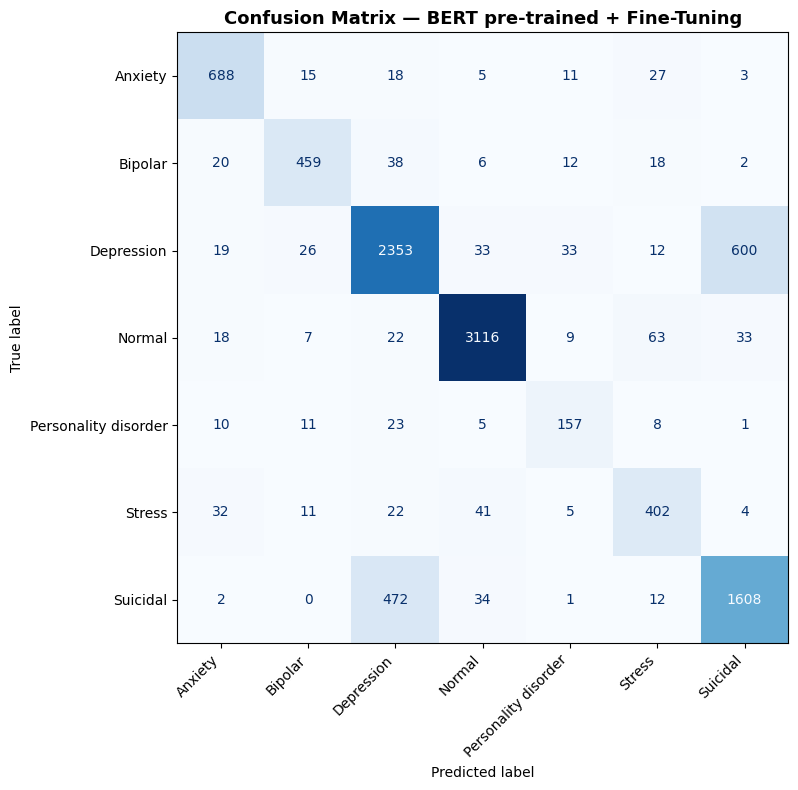

(0.8343307685000475,
 2.0922390044647097,
 0.342882330744792,
 array([2, 6, 0, ..., 1, 2, 6]))

In [ ]:
# =========================================================
# PRÉDICTIONS TEST
# =========================================================

print("Évaluation du modèle BERT...\n")

y_true_C, y_pred_C = predict(
    model,
    test_loader,
    device
)

# =========================================================
# MÉTRIQUES
# =========================================================

evaluate(
    "BERT pre-trained + Fine-Tuning",
    y_true_C,
    y_pred_C
)

---

## 4. Comparaison des modèles

Cette section synthétise les performances des trois modèles BERT et les compare avec les méthodes du notebook principal (Naive Bayes, K-Means).

**Ce que vous devez faire :**

### 4.1. Tableau récapitulatif

Construire un DataFrame pandas résumant les performances de chaque modèle :

| Modèle | Accuracy (test) | Temps d'entraînement (approx.) | Commentaire |
|---|---|---|---|
| Naive Bayes + TF-IDF | ? | ? | Référence notebook principal |
| K-Means + Word2Vec | ? | ? | Référence notebook principal |
| BERT sans fine-tuning (A) | ? | ? | |
| BERT avec fine-tuning (B) | ? | ? | |
| BERT spécialisé + fine-tuning (C) | ? | ? | |

In [ ]:
# 4.1 — Votre code ici

### 4.2. Visualisation comparative

**Ce que vous devez faire :**

Tracer un graphique en barres comparant l'accuracy des 5 modèles (Naive Bayes, K-Means, BERT A, BERT B, BERT C). Mettre en évidence le meilleur modèle.

> 💡 Utiliser une couleur distincte pour les modèles BERT vs les méthodes classiques, afin de rendre la comparaison visuelle plus lisible.

In [ ]:
# 4.2 — Votre code ici

### 4.3. Analyse et conclusion

Répondre aux questions suivantes dans cette cellule markdown :

1. **Quel modèle obtient la meilleure accuracy ?** Est-ce le résultat attendu ?
2. **Le gain du fine-tuning** (Modèle B vs Modèle A) : à combien estime-t-on l'apport du fine-tuning ?
3. **Modèle spécialisé vs BERT-base** (Modèle C vs Modèle B) : le modèle pré-entraîné sur des sentiments apporte-t-il un avantage mesurable ?
4. **Compromis coût/performance** : si l'on doit choisir un modèle pour un déploiement en production avec contraintes de temps de réponse, lequel recommandez-vous et pourquoi ?
5. **Quelles classes sont les plus difficiles** pour les modèles BERT ? Comparer avec les résultats de Naive Bayes.

*Votre analyse ici*